In [7]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [8]:
'''Define the tickers you want to run this analysis for.'''

def get_valid_tickers(max_attempts=3, fallback=["VOO", "AAPL", "AMZN", "MSFT"]):
    for attempt in range(1, max_attempts + 1):
        raw_input = input(f"Enter up to 4 stock tickers separated by commas (e.g. AAPL, MSFT, GOOGL, AMZN): ")
        candidates = [t.strip().upper() for t in raw_input.split(",")][:4]

        # Validate each ticker by trying to download a small amount of data
        valid = []
        invalid = []
        for ticker in candidates:
            data = yf.download(ticker, period="5d", progress=False, auto_adjust=True)
            if not data.empty:
                valid.append(ticker)
            else:
                invalid.append(ticker)

        if invalid:
            print(f"  ✗ Could not find data for: {', '.join(invalid)}")
            if attempt < max_attempts:
                print(f"  Please try again. ({max_attempts - attempt} attempt(s) remaining)\n")
            else:
                print(f"  Max attempts reached. Running analysis on fallback tickers: {', '.join(fallback)}\n")
                return fallback
        else:
            print(f"  ✓ All tickers valid: {', '.join(valid)}\n")
            return valid

TICKERS = get_valid_tickers()
START_DATE  = "2025-01-01"
END_DATE    = "2026-01-01"
RISK_FREE   = 0.05          # Annual risk-free rate (e.g. 10-yr Treasury yield)
TRADING_DAYS = 252

Enter up to 4 stock tickers separated by commas (e.g. AAPL, MSFT, GOOGL, AMZN): VOO, TSLA, QCOM, SBUX
  ✓ All tickers valid: VOO, TSLA, QCOM, SBUX



In [9]:
'''get your initial ticker prices'''

def fetch_prices(tickers, start, end):
    """Download adjusted closing prices from Yahoo Finance."""
    print(f"Downloading data for: {', '.join(tickers)} ...")
    raw = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)
    prices = raw["Close"]
    print(f"  Got {len(prices)} rows from {prices.index[0].date()} to {prices.index[-1].date()}\n")
    return prices


def generate_synthetic_prices(tickers, n_days=1000, seed=42):
    """ Simulate price paths using Geometric Brownian Motion. """
    rng  = np.random.default_rng(seed)
    # Assign each ticker a random annual drift and volatility
    params = {
        "AAPL":  (0.25, 0.28),
        "MSFT":  (0.22, 0.25),
        "GOOGL": (0.18, 0.30),
        "AMZN":  (0.20, 0.35),
    }
    dt   = 1 / TRADING_DAYS
    dates = pd.bdate_range(start=START_DATE, periods=n_days)
    data = {}
    for t in tickers:
        mu, sigma = params.get(t, (0.15, 0.25))
        shocks  = rng.normal((mu - 0.5 * sigma**2) * dt, sigma * np.sqrt(dt), n_days)
        log_returns = np.cumsum(shocks)
        data[t] = 100 * np.exp(log_returns)   # start all at $100
    return pd.DataFrame(data, index=dates)

In [10]:
'''Core Calculations'''

def compute_log_returns(prices: pd.DataFrame) -> pd.DataFrame:
    return np.log(prices / prices.shift(1)).dropna()


def compute_simple_returns(prices: pd.DataFrame) -> pd.DataFrame:
    return prices.pct_change().dropna()


def annualized_return(log_returns: pd.Series) -> float:
    mean_daily = log_returns.mean()
    annual_log = mean_daily * TRADING_DAYS
    return np.exp(annual_log) - 1


def annualized_volatility(log_returns: pd.Series) -> float:
    return log_returns.std() * np.sqrt(TRADING_DAYS)


def sharpe_ratio(ann_return: float, ann_vol: float, risk_free: float) -> float:
    return (ann_return - risk_free) / ann_vol


def build_summary_table(prices: pd.DataFrame) -> pd.DataFrame:
    """Compute all metrics for every ticker and return a clean DataFrame."""
    log_ret = compute_log_returns(prices)
    rows = []
    for ticker in prices.columns:
        r   = annualized_return(log_ret[ticker])
        vol = annualized_volatility(log_ret[ticker])
        sr  = sharpe_ratio(r, vol, RISK_FREE)
        rows.append({
            "Ticker":            ticker,
            "Ann. Return":       f"{r:.1%}",
            "Ann. Volatility":   f"{vol:.1%}",
            "Sharpe Ratio":      f"{sr:.2f}",
            "Total Return":      f"{(prices[ticker].iloc[-1] / prices[ticker].iloc[0] - 1):.1%}",
        })
    return pd.DataFrame(rows).set_index("Ticker")

In [13]:
'''The Summary Table definition'''

def plot_dashboard(prices: pd.DataFrame, summary: pd.DataFrame):
    """Four-panel dashboard: price history, returns dist, vol comparison, Sharpe."""
    log_ret = compute_log_returns(prices)
    tickers = prices.columns.tolist()
    colors  = ["#d9fc26", "#3bf7e5", "#f435a1", "#1bf572"]   # one per ticker

    fig = plt.figure(figsize=(16, 10), facecolor="#0D1117")
    fig.suptitle(
        "Return & Risk Dashboard",
        fontsize=20, fontweight="bold", color="white",
        fontfamily="monospace", y=0.97
    )
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

    panel_style = dict(facecolor="#161B22")
    tick_style  = dict(color="#8B949E", labelcolor="#8B949E", labelsize=9)

    # ── Panel 1: Normalised price history ──
    ax1 = fig.add_subplot(gs[0, 0], **panel_style)
    norm = prices / prices.iloc[0] * 100
    for t, c in zip(tickers, colors):
        ax1.plot(norm.index, norm[t], label=t, color=c, linewidth=1.5)
    ax1.set_title("Normalised Price (base = 100)", color="white", fontsize=11, pad=8)
    ax1.tick_params(axis="both", **tick_style)
    ax1.spines[:].set_color("#8B949E")
    ax1.yaxis.label.set_color("#8B949E")
    ax1.legend(fontsize=8, framealpha=0.2, labelcolor="white")
    ax1.set_facecolor("#161B22")

    # ── Panel 2: Return distribution (histogram) ──
    ax2 = fig.add_subplot(gs[0, 1], **panel_style)
    for t, c in zip(tickers, colors):
        ax2.hist(log_ret[t], bins=60, alpha=0.55, color=c, label=t, edgecolor="none")
    ax2.axvline(0, color="white", linewidth=0.8, linestyle="--", alpha=0.5)
    ax2.set_title("Daily Log-Return Distribution", color="white", fontsize=11, pad=8)
    ax2.tick_params(axis="both", **tick_style)
    ax2.spines[:].set_color("#30363D")
    ax2.set_facecolor("#161B22")
    ax2.legend(fontsize=8, framealpha=0.2, labelcolor="white")

    # ── Panel 3: Annualised volatility bar chart ──
    ax3 = fig.add_subplot(gs[1, 0], **panel_style)
    vols = [annualized_volatility(log_ret[t]) for t in tickers]
    bars = ax3.bar(tickers, vols, color=colors, width=0.5, edgecolor="none")
    for bar, v in zip(bars, vols):
        ax3.text(bar.get_x() + bar.get_width() / 2,
                 v + 0.005, f"{v:.1%}",
                 ha="center", va="bottom", color="white", fontsize=9)
    ax3.set_title("Annualised Volatility (σ)", color="white", fontsize=11, pad=8)
    ax3.tick_params(axis="both", **tick_style)
    ax3.spines[:].set_color("#30363D")
    ax3.set_ylim(0, max(vols) * 1.25)
    ax3.set_facecolor("#161B22")

    # ── Panel 4: Risk vs. Return scatter (Sharpe bubble) ──
    ax4 = fig.add_subplot(gs[1, 1], **panel_style)
    for t, c in zip(tickers, colors):
        r   = annualized_return(log_ret[t])
        vol = annualized_volatility(log_ret[t])
        sr  = sharpe_ratio(r, vol, RISK_FREE)
        ax4.scatter(vol, r, color=c, s=max(sr * 300, 30), alpha=0.85, zorder=3)
        ax4.annotate(t, (vol, r), textcoords="offset points",
                     xytext=(8, 4), color=c, fontsize=9, fontweight="bold")
    # Draw iso-Sharpe line
    vol_range = np.linspace(0.05, 0.55, 100)
    for sr_line in [0.5, 1.0, 1.5]:
        ax4.plot(vol_range, RISK_FREE + sr_line * vol_range,
                 "--", color="#30363D", linewidth=0.8)
        ax4.text(0.5, RISK_FREE + sr_line * 0.5 + 0.01,
                 f"SR={sr_line}", color="#8B949E", fontsize=7)
    ax4.set_xlabel("Annualised Volatility", color="#8B949E", fontsize=9)
    ax4.set_ylabel("Annualised Return", color="#8B949E", fontsize=9)
    ax4.set_title("Risk vs. Return (bubble size = Sharpe)", color="white", fontsize=11, pad=8)
    ax4.tick_params(axis="both", **tick_style)
    ax4.spines[:].set_color("#30363D")
    ax4.set_facecolor("#161B22")
    ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax4.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

    plt.savefig("project1_dashboard.png",
                dpi=150, bbox_inches="tight", facecolor="#0D1117")
    print("  Chart saved → project1_dashboard.png")
    plt.show()

  Got 250 rows from 2025-01-02 to 2025-12-31

  SUMMARY  (risk-free rate assumed: 5.0%)
       Ann. Return Ann. Volatility Sharpe Ratio Total Return
Ticker                                                      
QCOM         14.0%           38.3%         0.24        13.8%
SBUX         -6.3%           34.2%        -0.33        -6.2%
TSLA         18.8%           63.0%         0.22        18.6%
VOO          18.4%           18.5%         0.72        18.1%

  Deep-dive on VOO:
    Mean daily log-return : 0.00067
    Daily volatility      : 0.01163
    Annualised return     : 18.36%  (= exp(mean_daily × 252) − 1)
    Annualised volatility : 18.47%  (= daily_vol × √252)
    Sharpe Ratio          : 0.72   (= (return − rf) / vol)

Generating dashboard...
  Chart saved → project1_dashboard.png


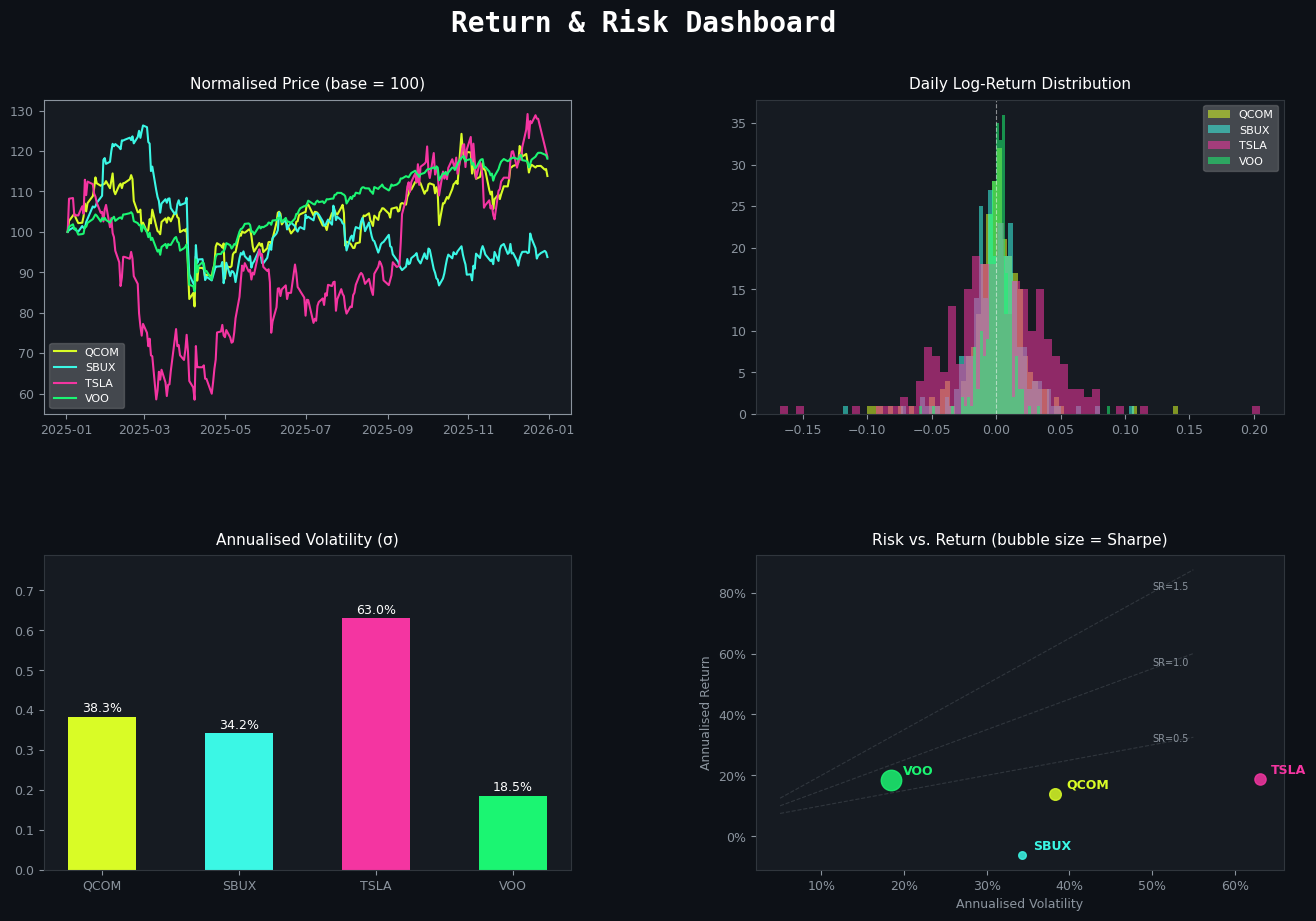

In [14]:
def main():
    # 1. Load data
    #if YFINANCE_AVAILABLE:
    prices = fetch_prices(TICKERS, START_DATE, END_DATE)
    #else:
     #   print("Using synthetic GBM price data for demo purposes.\n")
      #  prices = generate_synthetic_prices(TICKERS)

    # 2. Print summary table
    summary = build_summary_table(prices)
    print("=" * 55)
    print("  SUMMARY  (risk-free rate assumed: {:.1%})".format(RISK_FREE))
    print("=" * 55)
    print(summary.to_string())
    print("=" * 55)

    # 3. Extra: print a quick educational breakdown for the first ticker
    t0      = TICKERS[0]
    log_ret = compute_log_returns(prices)
    r       = annualized_return(log_ret[t0])
    vol     = annualized_volatility(log_ret[t0])
    sr      = sharpe_ratio(r, vol, RISK_FREE)

    print(f"\n  Deep-dive on {t0}:")
    print(f"    Mean daily log-return : {log_ret[t0].mean():.5f}")
    print(f"    Daily volatility      : {log_ret[t0].std():.5f}")
    print(f"    Annualised return     : {r:.2%}  (= exp(mean_daily × 252) − 1)")
    print(f"    Annualised volatility : {vol:.2%}  (= daily_vol × √252)")
    print(f"    Sharpe Ratio          : {sr:.2f}   (= (return − rf) / vol)")

    # 4. Plot dashboard
    print("\nGenerating dashboard...")
    plot_dashboard(prices, summary)


if __name__ == "__main__":
    main()

/Users/marinanikolaou
